# XGBC 06 — Interpretation

Review model-native feature importance and risk-probability behavior. Deeper SHAP analysis is deferred until finalist selection.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "peak_risk" / "xgboost"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "peak_risk" / "xgboost"

REPORTS_DIR, OUTPUTS_DIR


(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/peak_risk/xgboost'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/peak_risk/xgboost'))

In [3]:
importance = pd.read_csv(
    REPORTS_DIR / "XGBC_06_feature_importance.csv"
)
predictions = pd.read_parquet(
    OUTPUTS_DIR / "xgboost_classifier_validation_predictions.parquet"
)

In [4]:
display(importance.head(25))

,feature,importance
0,target_hour_sin,0.183296
1,target_hour,0.129320
2,target_season_Summer,0.059518
3,origin__Temp (°C),0.048384
4,target_lag_24h,0.048136
5,target_month_cos,0.044291
6,target_month_sin,0.040973
7,target_season_Winter,0.038279
8,fsa_M9W,0.037249
9,target_hour_cos,0.037018


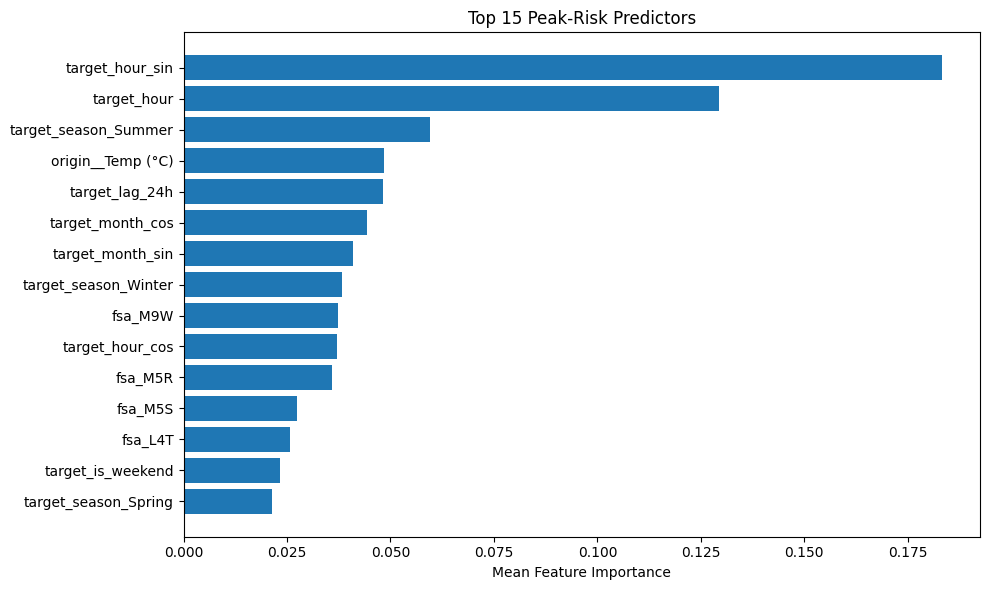

In [5]:
plot_data = importance.head(15).sort_values("importance")
plt.figure(figsize=(10, 6))
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("Mean Feature Importance")
plt.title("Top 15 Peak-Risk Predictors")
plt.tight_layout()
plt.show()


### Important interpretation note

Tree feature importance is model-specific and is not causal evidence. SHAP should be considered later only for finalist models.